In [ ]:
#install.packages("ggplot2")
#install.packages("reshape2")
#install.packages("lm.beta")
#install.packages("car", type = "binary", repos = "https://cloud.r-project.org")
#install.packages("see")
#install.packages("performance")
#install.packages("GGally")

# Projet d'Analyse de la Consommation Énergétique

### Section A: Analyse exploratoire

###### 1.1 — Statistiques descriptives

In [6]:
# CHARGEMENT DES DONNÉES
donnees <- read.csv("energy_data.csv", sep = ",", header = TRUE)
# Aperçu général du jeu de données
str(donnees)       # Structure : types de variables, nombre d'observations
summary(donnees)   # Statistiques descriptives de base

'data.frame':	1208 obs. of  9 variables:
 $ conso_energie  : num  181 277 317 277 258 ...
 $ surface        : num  59.5 114.7 137.4 157.6 127.7 ...
 $ hauteur_plafond: num  2.69 2.34 3.18 2.44 3.04 ...
 $ isolation      : num  7.6 7.18 9.08 8.5 4.68 ...
 $ nbr_occupants  : int  2 4 3 4 4 5 5 4 4 4 ...
 $ temperature_moy: num  9.14 14.14 5.13 9.35 10.3 ...
 $ orientation    : num  4.19 5.92 1.43 4.42 4.9 ...
 $ type_energie   : int  2 1 1 1 2 2 2 2 3 2 ...
 $ age_batiment   : int  22 56 34 31 40 46 50 40 56 35 ...


 conso_energie      surface       hauteur_plafond   isolation    
 Min.   :104.6   Min.   : 31.04   Min.   :1.522   Min.   :1.161  
 1st Qu.:192.6   1st Qu.: 88.59   1st Qu.:2.317   1st Qu.:4.628  
 Median :228.8   Median :118.56   Median :2.520   Median :5.904  
 Mean   :226.7   Mean   :120.00   Mean   :2.517   Mean   :5.908  
 3rd Qu.:260.6   3rd Qu.:148.96   3rd Qu.:2.718   3rd Qu.:7.242  
 Max.   :347.5   Max.   :260.94   Max.   :3.462   Max.   :9.895  
 nbr_occupants   temperature_moy    orientation      type_energie  
 Min.   :1.000   Min.   : 0.9133   Min.   :-4.024   Min.   :1.000  
 1st Qu.:3.000   1st Qu.: 9.3409   1st Qu.: 3.199   1st Qu.:1.000  
 Median :4.000   Median :12.1154   Median : 4.938   Median :1.000  
 Mean   :4.019   Mean   :11.9515   Mean   : 4.944   Mean   :1.696  
 3rd Qu.:5.000   3rd Qu.:14.5540   3rd Qu.: 6.741   3rd Qu.:2.000  
 Max.   :8.000   Max.   :23.8856   Max.   :13.356   Max.   :3.000  
  age_batiment  
 Min.   : 1.00  
 1st Qu.:25.00  
 Median :38

Le jeu de données comprend 1208 observations et 9 variables. La variable cible conso_energie et les variables explicatives physiques (surface, hauteur_plafond, isolation, temperature_moy, orientation) sont de type numérique (num), Les variables nbr_occupants et age_batiment sont de type entier (int), ce qui est cohérent avec leur nature, La variable type_energie est initialement identifiée comme un entier (int). Cependant, elle représente des catégories distinctes (ex: 1 = Gaz, 2 = Électricité, 3 = Solaire).

In [7]:
#Convertir les variables type_energie  en facteurs
donnees$type_energie <- as.factor(donnees$type_energie)

La variable type_energie a été convertie en facteur (as.factor). Cette transformation est indispensable pour que le modèle traite chaque source d'énergie comme un groupe indépendant et non comme une valeur numérique continue

Statistiques descriptives: On observe une grande hétérogénéité dans le parc immobilier étudié : alors que la surface moyenne est de 120 m², les habitations varient de 31 m² à plus de 260 m².
La consommation énergétique moyenne s'établit à 226,7 kWh. On note toutefois une dispersion importante, les valeurs s'étendant de 104,6 à 347,5 kWh, parallèlement à une grande diversité dans l'âge des bâtiments (de 1 à 73 ans).

PI : La variable orientation, bien que définie initialement sur une échelle de 1 à 10 dans l’énoncé, apparaît dans le dataset sous forme de valeurs continues incluant des valeurs négatives. Cela indique qu’une transformation préalable a été appliquée. Par conséquent, aucune transformation supplémentaire n’a été effectuée et la variable a été utilisée telle quelle dans le modèle de régression.

Contrairement aux variables quantitatives précédentes, la variable type_energie est de nature catégorielle. Le calcul de statistiques classiques n'étant pas pertinent pour ce type de donnée, nous avons opté pour une analyse de fréquences. Cette approche permet d'identifier la répartition du parc immobilier selon les sources d'énergie utilisées et de mettre en évidence les catégories dominantes au sein de l'échantillon


In [8]:
table(donnees$type_energie) 
prop.table(table(donnees$type_energie)) * 100


  1   2   3 
610 355 243 


       1        2        3 
50.49669 29.38742 20.11589 

L'analyse de la variable qualitative "Type d'énergie" révèle une prédominance du Type 1, qui concerne plus de la moitié de l'échantillon (50,5 %). Les types 2 et 3 sont moins représentés, comptant respectivement pour 29,4 % et 20,1 % des habitations étudiées.

###### 1.2 — Représentation graphique des corrélations

Loading required package: ggplot2

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


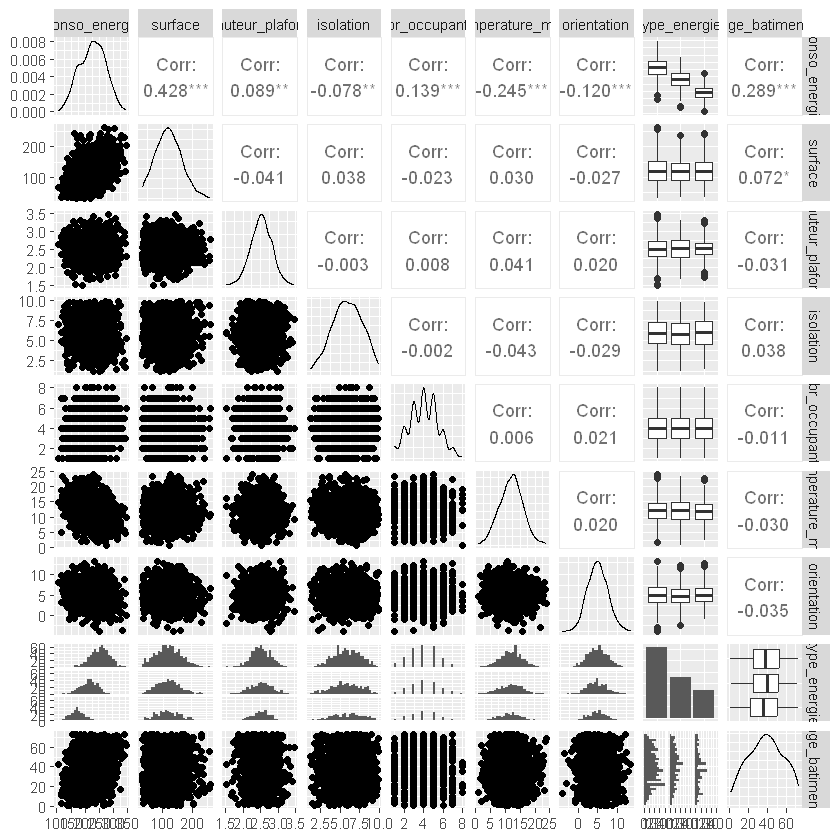

In [9]:
# Charger l extension GGally
library(GGally)
# Matrice de nuage de points et corrélations
ggpairs(donnees)

Variables significativement corrélées à conso_energie :
La matrice révèle que plusieurs variables explicatives ont une corrélation statistiquement significative avec la consommation énergétique :
surface (r = 0.428) — C'est la corrélation la plus forte et la plus importante. Plus la surface habitable est grande, plus la consommation énergétique augmente. 
temperature_moy (r = -0.245) — Corrélation négative significative. Plus la température extérieure moyenne est élevée, moins le bâtiment consomme d'énergie. 
age_batiment (r = 0.289) — Corrélation positive significative. Les bâtiments plus anciens tendent à consommer davantage.
nbr_occupants (r = 0.139) — Corrélation positive modéré. Un plus grand nombre d'occupants est associé à une consommation plus élevée.

Les boxplots de type_energie montrent une tendance visuelle : les bâtiments chauffés à l'électricité (groupe 1) tendent à consommer davantage que ceux au gaz (groupe 2) ou aux énergies renouvelables (groupe 3). Étant donné la nature catégorielle de cette variable, une corrélation de Pearson ne peut être calculée, mais la variation observée entre les groupes suggère une association potentielle avec la consommation énergétique à confirmer avec un test statistique.


In [10]:
anova_model <- aov(conso_energie ~ type_energie, data = donnees)
# Résultat
summary(anova_model) # p_value inferieur a 5% le type d’énergie influence la consommation


               Df  Sum Sq Mean Sq F value Pr(>F)    
type_energie    2 1307184  653592   644.7 <2e-16 ***
Residuals    1205 1221654    1014                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Un test ANOVA confirme que cette différence est statistiquement significative (p < 0.05), indiquant que le type d'énergie est bien associé à la consommation énergétique.

###### 1.2 — Étude de la linéarité (graphiques conso_energie vs chaque variable)

Loading required package: carData



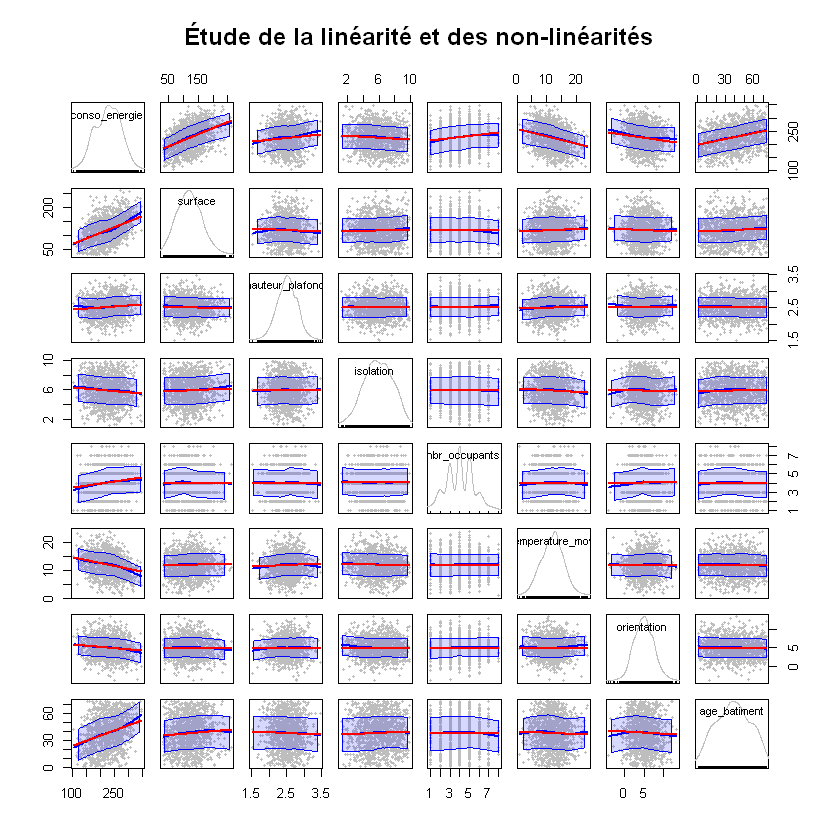

In [11]:
library(car)

# Sélection des variables numériques
vars_num <- donnees[, sapply(donnees, is.numeric)]

# Graphique optimisé pour le maximum de points (A2)
scatterplotMatrix(vars_num,
                  # 'smooth' crée la courbe de tendance (essentielle pour l'analyse des non-linéarités)
                  smooth = list(smoother = loessLine, col.smooth = "blue", col.var = "blue", lty.smooth = 1),
                  # 'regLine' montre la linéarité théorique
                  regLine = list(col = "red", lwd = 2),
                  pch = 19,
                  cex = 0.5,
                  col = "grey", # Points en gris pour faire ressortir les lignes
                  main = "Étude de la linéarité et des non-linéarités")


Ligne rouge = tendance linéaire (régression)
Enveloppe bleue = intervalle de confiance autour de la tendance
Diagonale = distribution de chaque variable (courbe de densité)

En observant la première ligne de la matrice (conso_energie vs chaque variable) :

<font color="blue">surface → conso_energie :</font> la relation la plus nette de la matrice. La pente positive est prononcée, l'enveloppe bleue est resserrée, et les points suivent globalement la droite.

<font color="blue">temperature_moy → conso_energie :</font> relation négative modérée. Un climat plus chaud réduit les besoins en chauffage. La tendance est linéaire.

<font color="blue">isolation → conso_energie :</font> La droite est légèrement négative mais presque plate. La relation linéaire est faible.

<font color="blue">La relation age_batiment → conso_energie </font> est linéaire positive. Plus le bâtiment est ancien, plus il consomme.La relation linéaire semble respectée.

surface, isolation, temperature_moy et age_batiment sont les variables les plus prometteuses pour modéliser conso_energie.

La matrice  ne révèle pas de non-linéarité de courbure clairement visible pour aucune des variables. Les tendances observées sont globalement compatibles avec une hypothèse de linéarité. l'une des  variables se distingue cependant par sa structure plutôt que par sa courbure : nbr_occupants  présente une distribution discrètes.

Un diagnostic complémentaire (LOESS) sera réalisé pour détecter d'éventuelles non-linéarités plus subtiles non visibles à cette échelle.


### Section B: Création du modèle de régression linéaire multiple

###### 2.1 — Construction du modèle

In [12]:
# Création du modèle de régression linéaire multiple
modele_complet <- lm(conso_energie ~ ., data = donnees)

# Affichage des résultats
summary(modele_complet)



Call:
lm(formula = conso_energie ~ ., data = donnees)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.261 -10.424  -0.234  10.736  54.269 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     180.03863    4.89264   36.80   <2e-16 ***
surface           0.44363    0.01039   42.70   <2e-16 ***
hauteur_plafond  17.87955    1.53305   11.66   <2e-16 ***
isolation        -2.98803    0.24478  -12.21   <2e-16 ***
nbr_occupants     5.26413    0.30756   17.12   <2e-16 ***
temperature_moy  -3.26416    0.11601  -28.14   <2e-16 ***
orientation      -1.90080    0.17345  -10.96   <2e-16 ***
type_energie2   -41.40284    1.04279  -39.70   <2e-16 ***
type_energie3   -83.60762    1.18477  -70.57   <2e-16 ***
age_batiment      0.58445    0.02489   23.49   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 15.6 on 1198 degrees of freedom
Multiple R-squared:  0.8848,	Adjusted R-squared:  0.8839 
F-statistic:  1

<font color="blue">Significativité des variables:</font>
Toutes les variables du modèle sont statistiquement significatives p_value trop petite au seuil de 5%.

<font color="blue">Interprétation des Coefficients :</font>
•	surface (0,44) : Pour chaque m supplémentaire, la consommation augmente de 0,44 unité.
•	hauteur_plafond (17,88) : Augmenter le plafond d'un mètre augmente la consommation de près de 18 unités.
•	isolation (-2,98) : L'effet est négatif, ce qui est logique : une meilleure isolation réduit la consommation.
•	temperature_moy (-3,26) : Plus il fait chaud à l'extérieur, moins on consomme.
•	type_energie est une variable catégorielle avec 3 groupes (1, 2, 3). R ne peut pas utiliser directement des catégories dans une régression, il faut les transformer en variables 0/1, appelées variables muettes.
R choisit automatiquement le groupe 1 (électrique) comme référence et crée deux variables 
Les coefficients -41.40 et -83.61 sont comparés au groupe de référence (groupe 1) :
•	Un bâtiment au gaz consomme en moyenne 41.40 kWh/m²/an de moins qu'un bâtiment électrique équivalent.
•	Un bâtiment aux renouvelables consomme en moyenne 83.61 kWh/m²/an de moins qu'un bâtiment électrique équivalent

<font color="blue">Interprétation du R²:</font>
Le modèle affiche un R² = 0.8848, ce qui signifie que 88.48% de la variabilité de la consommation énergétique est expliquée par les 8 variables du modèle. Le R² ajusté = 0.8839, très proche du R².
Bien que le R² soit élevé, il ne garantit pas à lui seul la validité du modèle. Les conditions d'application : normalité des résidus, homoscédasticité et absence de multicolinéarité doivent être vérifiées avant de conclure sur la fiabilité des estimations.

D’un point de vue métier, ce modèle aide à identifier les principaux leviers de réduction de la consommation énergétique, comme l’isolation et le choix du type d’énergie. Il met également en évidence l’importance des décisions de conception. Toutefois, ces résultats doivent être interprétés avec prudence, car certaines variables pertinentes (comme le comportement des occupants ou la qualité des équipements) ne sont pas incluses dans le modèle.
De plus, l’absence de standardisation limite la comparaison directe de l’importance relative des variables.

###### 2.2 — Vérification des conditions d’application du modèle

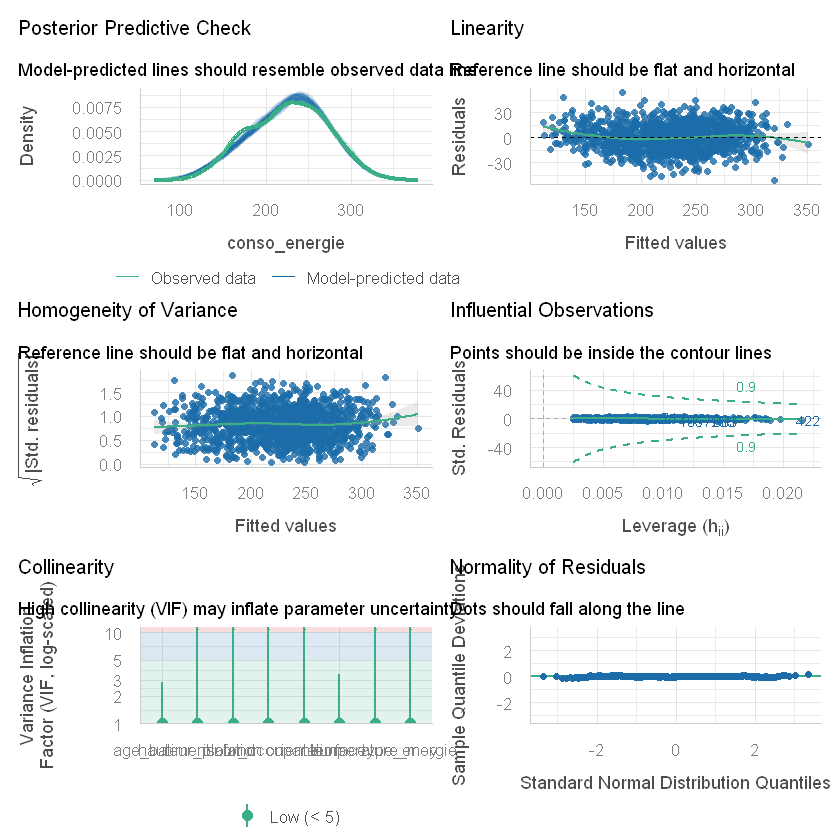

In [13]:
library(performance)
check_model(modele_complet)

<font color="blue">Posterior Predictive Check :</font>
La distribution prédite par le modèle (courbe bleue) suit de très près la distribution observée (courbe verte), confirmant que le modèle capture bien la structure des données 

<font color="blue">Linearity :</font>
Les résidus sont répartis aléatoirement autour de zéro. La ligne de référence est quasi horizontale ce qui confirme l’hypothèse de linéarité entre les variables explicatives et la variable cible

<font color="blue">Homogeneity of Variance :</font>
Le graphique d'homogénéité de la variance ne montre pas de pattern en entonnoir , la dispersion des résidus reste relativement constante le long des valeurs ajustées.

<font color="blue">Collinearity :</font>
Tous les VIF sont inférieurs à 5 (représentés en vert — Low < 5), ce qui indique l'absence de multicolinéarité problématique entre les variables explicatives.

<font color="blue">Influential Observations :</font>
La quasi-totalité des points se situe à l'intérieur des contours de Cook, indiquant qu'il n'y a pas d'observations influentes susceptibles de distordre le modèle.

<font color="blue">Q-Q (Normality of Residuals) :</font>
Les points suivent très bien la droite diagonale sur l'ensemble de la distribution. La condition de normalité des résidus est respectée .
L'ensemble des conditions d'application du modèle de régression linéaire multiple semble globalement respecté..


### Section C : Sélection des variables

Dans cette section, nous cherchons à identifier le modèle le plus parcimonieux : celui qui offre la meilleure précision avec le minimum de variables nécessaires. Nous allons comparer deux approches :
1. **Sélection exhaustive (Meilleur sous-ensemble)** : Analyse de toutes les combinaisons possibles.
2. **Sélection séquentielle (Stepwise AIC)** : Procédure pas à pas pour valider la robustesse des choix.

1. **Meilleur sous-ensemble** :
   
Cette méthode explore de manière exhaustive toutes les combinaisons possibles de variables (2^9 = 512 combinaisons) pour garantir de trouver le modèle optimal selon les critères statistiques.

In [14]:
library(leaps)

choix_sous_ensemble <- regsubsets(conso_energie ~ ., 
                                  data = donnees, 
                                  nbest = 1, 
                                  nvmax = 9)

summary_choix <- summary(choix_sous_ensemble)
summary_choix

Subset selection object
Call: regsubsets.formula(conso_energie ~ ., data = donnees, nbest = 1, 
    nvmax = 9)
9 Variables  (and intercept)
                Forced in Forced out
surface             FALSE      FALSE
hauteur_plafond     FALSE      FALSE
isolation           FALSE      FALSE
nbr_occupants       FALSE      FALSE
temperature_moy     FALSE      FALSE
orientation         FALSE      FALSE
type_energie2       FALSE      FALSE
type_energie3       FALSE      FALSE
age_batiment        FALSE      FALSE
1 subsets of each size up to 9
Selection Algorithm: exhaustive
         surface hauteur_plafond isolation nbr_occupants temperature_moy
1  ( 1 ) " "     " "             " "       " "           " "            
2  ( 1 ) "*"     " "             " "       " "           " "            
3  ( 1 ) "*"     " "             " "       " "           " "            
4  ( 1 ) "*"     " "             " "       " "           "*"            
5  ( 1 ) "*"     " "             " "       " "           "*"  

In [15]:
# Tableau de bord des 3 critères justifiant quel modèle est statistiquement optimal :
criteres_tab <- cbind(summary_choix$which, 
                      round(cbind(Adjr2 = summary_choix$adjr2, 
                                  Cp = summary_choix$cp, 
                                  BIC = summary_choix$bic), 3))
criteres_tab

,(Intercept),surface,hauteur_plafond,isolation,nbr_occupants,temperature_moy,orientation,type_energie2,type_energie3,age_batiment,Adjr2,Cp,BIC
1,1,0,0,0,0,0,0,0,1,0,0.372,5321.271,-548.500
2,1,1,0,0,0,0,0,0,1,0,0.549,3477.210,-943.128
3,1,1,0,0,0,0,0,1,1,0,0.692,1996.033,-1396.544
4,1,1,0,0,0,1,0,1,1,0,0.768,1208.178,-1732.363
5,1,1,0,0,0,1,0,1,1,1,0.819,682.735,-2024.175
6,1,1,0,0,1,1,0,1,1,1,0.846,397.226,-2217.719
7,1,1,0,1,1,1,0,1,1,1,0.860,257.811,-2323.053
8,1,1,1,1,1,1,0,1,1,1,0.872,128.094,-2431.014
9,1,1,1,1,1,1,1,1,1,1,0.884,10.000,-2539.322


L'analyse montre que la performance du modèle s'améliore à chaque ajout de variable. 

Le **R² ajusté** atteint son maximum **(0.884)** avec le modèle complet.

Pour le **BIC**, il continue de diminuer jusqu'au modèle incluant toutes les variables **(valeur la plus basse : -2539.32)**. 

De même, le **Cp de Mallows (10)** est égal au nombre de paramètres (9+1), ce qui indique un modèle avec un biais minimal.

On observe que **l'orientation** est la dernière variable intégrée (modèle 9). Son impact est statistiquement significatif selon le BIC, mais son poids reste secondaire par rapport à la surface ou au type d'énergie.

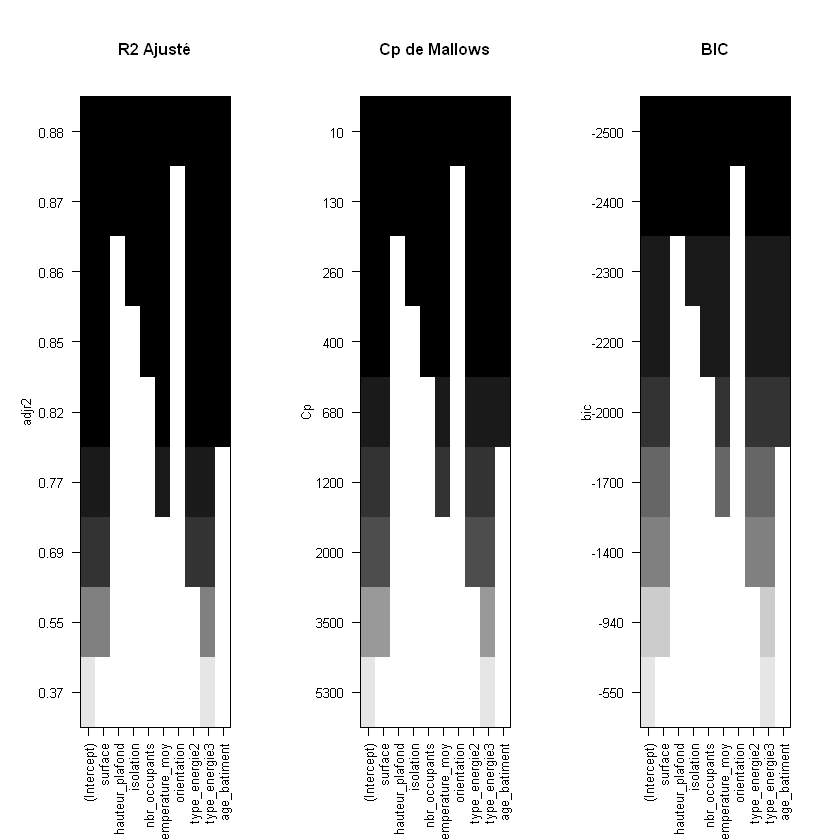

In [16]:
# Visualisation comparative :
par(mfrow=c(1,3))
plot(choix_sous_ensemble, scale = "adjr2", main = "R2 Ajusté")
plot(choix_sous_ensemble, scale = "Cp", main = "Cp de Mallows")
plot(choix_sous_ensemble, scale = "bic", main = "BIC")

Avec 1208 observations, le stepwise BIC risque d'exclure des variables qui ont un impact réel pour favoriser la simplicité extrême du modèle.
Pour ce projet, l'objectif principal est de prédire le plus précisément possible la consommation des bâtiments afin de cibler les besoins énergétiques réels. Nous avons donc choisi l'AIC minimise le risque de négliger des variables utiles comme l'orientation, tout en conservant un modèle statistiquement robuste.

In [17]:
# Sélection Stepwise :

library(MASS)

modele_step <- stepAIC(modele_complet, direction = "both", trace = FALSE)
summary(modele_step)


Call:
lm(formula = conso_energie ~ surface + hauteur_plafond + isolation + 
    nbr_occupants + temperature_moy + orientation + type_energie + 
    age_batiment, data = donnees)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.261 -10.424  -0.234  10.736  54.269 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     180.03863    4.89264   36.80   <2e-16 ***
surface           0.44363    0.01039   42.70   <2e-16 ***
hauteur_plafond  17.87955    1.53305   11.66   <2e-16 ***
isolation        -2.98803    0.24478  -12.21   <2e-16 ***
nbr_occupants     5.26413    0.30756   17.12   <2e-16 ***
temperature_moy  -3.26416    0.11601  -28.14   <2e-16 ***
orientation      -1.90080    0.17345  -10.96   <2e-16 ***
type_energie2   -41.40284    1.04279  -39.70   <2e-16 ***
type_energie3   -83.60762    1.18477  -70.57   <2e-16 ***
age_batiment      0.58445    0.02489   23.49   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residu

**Le modèle final présente une performance exceptionnelle :**
- R2 ajusté de 0.8839, donc le modèle explique **88,4 %** de la variance de la consommation énergétique, ce qui garantit la fiabilité des prédictions.
- Significativité globale : La p-value est inférieure à 2,2e-16, le modéle est donc effectivement robuste.
- Significativité individuelle : p-value extrêmement faible pour toutes les variables. Donc chacune d'elles a un effet.

L'utilisation des coefficients **standardisés** est essentielle pour pouvoir identifier le poids réel de chaque facteur :

In [18]:
library(lm.beta)

coeffs_finaux <- lm.beta(modele_step)
summary(coeffs_finaux)


Call:
lm(formula = conso_energie ~ surface + hauteur_plafond + isolation + 
    nbr_occupants + temperature_moy + orientation + type_energie + 
    age_batiment, data = donnees)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.261 -10.424  -0.234  10.736  54.269 

Coefficients:
                 Estimate Standardized Std. Error t value Pr(>|t|)    
(Intercept)     180.03863           NA    4.89264   36.80   <2e-16 ***
surface           0.44363      0.42092    0.01039   42.70   <2e-16 ***
hauteur_plafond  17.87955      0.11465    1.53305   11.66   <2e-16 ***
isolation        -2.98803     -0.12010    0.24478  -12.21   <2e-16 ***
nbr_occupants     5.26413      0.16810    0.30756   17.12   <2e-16 ***
temperature_moy  -3.26416     -0.27688    0.11601  -28.14   <2e-16 ***
orientation      -1.90080     -0.10771    0.17345  -10.96   <2e-16 ***
type_energie2   -41.40284     -0.41222    1.04279  -39.70   <2e-16 ***
type_energie3   -83.60762     -0.73252    1.18477  -70.57   <2e-16 ***
ag

Classons maintenant les variables par ordre d'importance :
1. **Le type d'Énergie (Renouvelable : -0,732) :** le prédicteur le plus puissant du modèle : passer aux énergies renouvelables réduit très significativement la consommation par rapport à l'électrique.
2. **La surface (0,421) :** Plus la surface est grande, plus la consommation augmente de manière prévisible.
3. **Le type d'Énergie (Gaz : -0,412) :** Le choix du gaz réduit lui aussi la consommation comparé au tout-électrique.
4. **La température moyenne (-0,277) :** et l'âge du bâtiment (0,232) occupent une importance intermédiaire.
5. **Le nombre d'occupants (0,168) :** moins d'influence que les caractéristiques précédentes liées directement aux bâtiments.
6. **L'solation (-0,120), La hauteur sous plafond (0,115) et L'orientation (-0,108)** sont les variables avec les poids standardisés les plus faibles, bien que nous avons dit précédemment qu'elles sont très significatives. On peut donc conclure que leur capacité à faire varier la consommation est limitée comparée aux autres facteurs.

### Section D: Amélioration du modèle

###### 4.1 — Ajout d'un terme polynomial

Afin d'identifier la variable la plus pertinente pour l'introduction d'un terme polynomial, nous avons comparé graphiquement la droite de régression linéaire avec un lissage non-paramétrique LOESS.

Warning message:
"attributes are not identical across measure variables; they will be dropped"
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"pseudoinverse used at 0.99"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"neighborhood radius 1.01"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"reciprocal condition number  0"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"There are other near singularities as well. 4.0401"


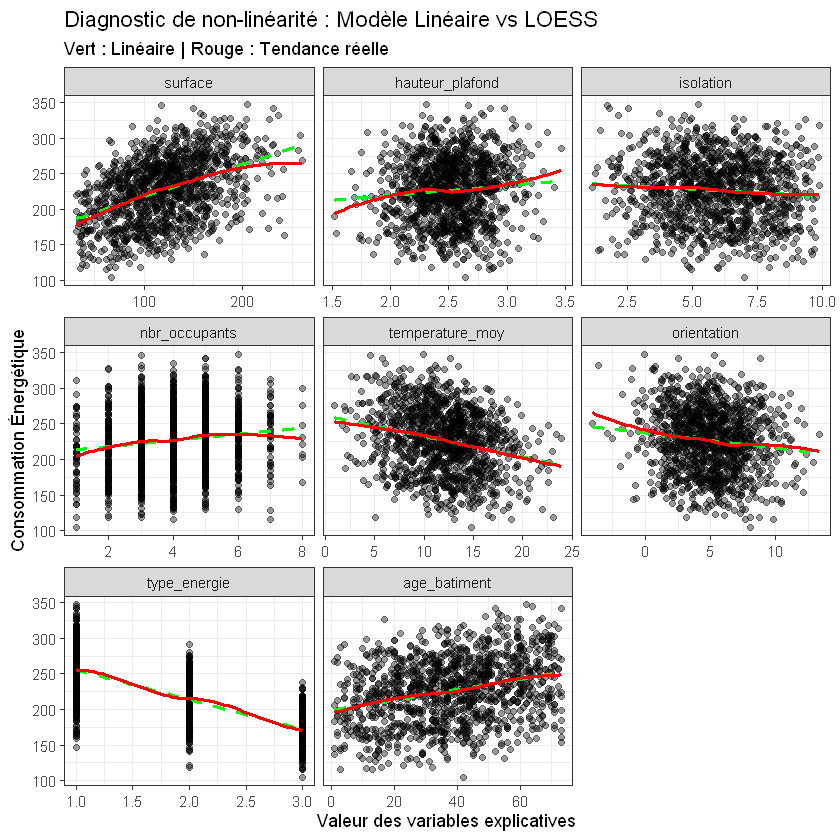

In [19]:
library(reshape2)

# 1. Transformer les données au format long
df_long <- melt(donnees, id.vars = "conso_energie")
# 2. FORCE la colonne value en numérique
df_long$value <- as.numeric(as.character(df_long$value))

# 2. Générer la grille de graphiques comparative
ggplot(df_long, aes(x = value, y = conso_energie)) +
  geom_point(alpha = 0.4) +
  # Ligne VERTE pointillée : ce que le modèle linéaire "voit"
  geom_smooth(method = "lm", se = FALSE, color = "green", linetype = "dashed") + 
  # Ligne ROUGE : la réalité de la tendance (potentiellement courbe)
  geom_smooth(method = "loess", se = FALSE, color = "red",span = 0.75) + 
  facet_wrap(~ variable, scales = "free_x") +
  labs(title = "Diagnostic de non-linéarité : Modèle Linéaire vs LOESS",
       subtitle = "Vert : Linéaire | Rouge : Tendance réelle",
       x = "Valeur des variables explicatives",
       y = "Consommation Énergétique") +
  theme_bw()


L’analyse exploratoire a mis en évidence une non-linéarité dans la relation entre la variable surface et la consommation énergétique, la ligne rouge s'infléchit, suggérant que l’effet de cette variable n’est pas constant. En pratique, cela peut s’expliquer par le fait que l’augmentation de la surface n’entraîne pas une hausse proportionnelle de la consommation, en raison d’effets d’échelle (meilleure répartition thermique dans les grands espaces).

Afin de capturer cette relation, un terme polynomial de degré 2 (surface²) sera introduit dans le modèle.

Une légère non-linéarité est également observée pour la variable temperature_moy, suggérant qu’une transformation pourrait améliorer le modèle, bien que cet effet soit moins marqué que pour la variable surface.

######  — Estimation et Comparaison des modèles (Linéaire vs Polynomial)

Après avoir identifié visuellement une courbure pour la variable surface, nous procédons à l'estimation de deux modèles pour quantifier ce gain de précision.

###### 4.1.1 — Estimation du modèle linéaire (Base)

In [20]:
# Modèle linéaire simple
model_L <- lm(conso_energie ~ surface, data = donnees)
summary(model_L)


Call:
lm(formula = conso_energie ~ surface, data = donnees)

Residuals:
     Min       1Q   Median       3Q      Max 
-117.897  -31.220    3.674   31.320  119.845 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 172.62130    3.50025   49.32   <2e-16 ***
surface       0.45102    0.02743   16.44   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 41.39 on 1206 degrees of freedom
Multiple R-squared:  0.1831,	Adjusted R-squared:  0.1825 
F-statistic: 270.4 on 1 and 1206 DF,  p-value: < 2.2e-16


Pour chaque augmentation d'un mètre carré de la surface du bâtiment, la consommation énergétique augmente en moyenne de 0,45 unité (kWh). La p-value est extrêmement faible (< 2e-16), Cela prouve que la surface a un impact majeur sur la consommation. Bien que le modèle linéaire soit très significatif, il suppose que l'impact de la surface est constant (toujours +0,45 par m^2). Or, notre diagnostic visuel (LOESS) suggérait que cet impact diminue légèrement pour les très grands bâtiments. C'est pourquoi nous avons introduit le terme polynomial.

###### 4.1.2 — Estimation du modèle polynomial

In [21]:
# Modèle polynomial de degré 2
model_P <- lm(conso_energie ~ poly(surface, 2, raw = TRUE), 
              data = donnees, 
              na.action = na.omit)
summary(model_P)



Call:
lm(formula = conso_energie ~ poly(surface, 2, raw = TRUE), data = donnees, 
    na.action = na.omit)

Residuals:
     Min       1Q   Median       3Q      Max 
-110.032  -31.119    4.412   31.511  117.579 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)    
(Intercept)                   155.518428   7.523690  20.670  < 2e-16 ***
poly(surface, 2, raw = TRUE)1   0.759671   0.123341   6.159 9.95e-10 ***
poly(surface, 2, raw = TRUE)2  -0.001224   0.000477  -2.566   0.0104 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 41.29 on 1205 degrees of freedom
Multiple R-squared:  0.1876,	Adjusted R-squared:  0.1862 
F-statistic: 139.1 on 2 and 1205 DF,  p-value: < 2.2e-16


Dans le modèle polynomial , on observe que le terme au carré (poly(surface, 2, raw = TRUE)2) possède une p-value de 0,0104.

• Interprétation : Cette valeur étant inférieure au seuil de 0,05, nous confirmons que la courbure de la relation entre la surface et la consommation n'est pas due au hasard. Le modèle polynomial est donc légitime.

• Signe du coefficient : Le coefficient est négatif (-0.001224). Cela confirme mathématiquement ce que nous avons vu sur le graphique : la consommation augmente avec la surface, mais de moins en moins vite (courbe concave). En comparant les deux modèles, on note une progression des indicateurs de performance :

• R-squared ajusté : Il passe de 0,1831 (modèle linéaire) à 0,1876 (modèle polynomial). Bien que l'augmentation paraisse faible, elle indique que la prise en compte de la courbure permet d'expliquer une part plus importante de la variance de la consommation confirmant que cette forme polynomiale est statistiquement préférable à une simple droite.

###### 4.1.3 — Comparaison par l'AIC


In [22]:
AIC(model_L, model_P)

,df,AIC
,<dbl>,<dbl>
model_L,3,12426.84
model_P,4,12422.26


Le modèle polynomial présente un AIC plus faible (12422.26) que le modèle linéaire (12426.84), indiquant une meilleure qualité d’ajustement en tenant compte de la complexité du modèle. La différence d’AIC étant modérée (≈ 4.6), le modèle P est légèrement préférable.

###### 4.1.4 — Application du terme polynomial sur le model complet

In [23]:
m_poly <- lm(conso_energie ~ poly(surface, 2, raw = TRUE) + 
               hauteur_plafond + 
               isolation + 
               nbr_occupants + 
               temperature_moy + 
               orientation + 
               type_energie + 
               age_batiment, 
             data = donnees)

summary(m_poly)


Call:
lm(formula = conso_energie ~ poly(surface, 2, raw = TRUE) + hauteur_plafond + 
    isolation + nbr_occupants + temperature_moy + orientation + 
    type_energie + age_batiment, data = donnees)

Residuals:
    Min      1Q  Median      3Q     Max 
-44.529 -10.234  -0.123  10.411  50.495 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    1.561e+02  5.283e+00  29.554   <2e-16 ***
poly(surface, 2, raw = TRUE)1  8.804e-01  4.506e-02  19.536   <2e-16 ***
poly(surface, 2, raw = TRUE)2 -1.732e-03  1.743e-04  -9.939   <2e-16 ***
hauteur_plafond                1.818e+01  1.474e+00  12.332   <2e-16 ***
isolation                     -2.882e+00  2.356e-01 -12.232   <2e-16 ***
nbr_occupants                  5.165e+00  2.959e-01  17.455   <2e-16 ***
temperature_moy               -3.283e+00  1.116e-01 -29.431   <2e-16 ***
orientation                   -1.983e+00  1.670e-01 -11.876   <2e-16 ***
type_energie2                 -4.1

Le terme au carré (poly...2) est extrêmement significatif (p < 2e-16).
La relation entre la surface et la consommation n'est pas une ligne droite parfaite. Elle est légèrement courbée (concave, car le coefficient est négatif : -1.732e-03. Cela signifie que l'augmentation de la consommation ralentit légèrement pour les très grands bâtiments.

###### 4.1.5 — Validation statistique par le test ANOVA

In [24]:
# Comparaison du modèle sans terme polynomial avec le modèle avec terme polynomial sur la surface
anova(modele_complet, m_poly)


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1198,291395.2,NA,NA,NA,NA
2,1197,269179.3,1,22215.88,98.79068,2.016828e-22


La p-value obtenue est extrêmement faible. Cela signifie que nous rejetons l'hypothèse nulle : l'amélioration de la précision du modèle n'est pas due au hasard.

###### 4.2 — Ajout d’un effet d’interaction

###### 4.2.1 —  Détection d’interaction 

La détection de l'effet d'interaction prend racine dans l'analyse du graphique de diagnostic de non-linéarité. En observant les facettes des variables explicatives, deux constats majeurs nous ont orientés vers l'existence d'une interaction :

1.La domination de la variable Surface : La facette "surface" montre la pente la plus prononcée, confirmant qu'il s'agit du moteur principal de la consommation. Cependant, on observe une dispersion importante des points autour de la tendance réelle (ligne rouge).

2.La segmentation par Type d'énergie : La facette "type_energie" montre des niveaux de consommation très distincts (paliers). Le raisonnement de détection : En croisant ces deux observations, l'hypothèse émise est que la dispersion observée dans la facette "surface" n'est pas aléatoire, mais qu'elle est structurée par le "type d'énergie". Nous avons donc suspecté que la "vitesse" à laquelle la surface fait monter la consommation dépend de la catégorie d'énergie utilisée.

d'un point de vu métier, l'interaction suggère que l'efficacité énergétique d'un bâtiment ne dépend pas uniquement de sa taille, mais de la technologie de chauffage installée. Par exemple, une grande surface chauffée à l'électricité pourrait voir sa consommation s'envoler plus rapidement qu'une surface identique chauffée par un système de pompes à chaleur ou de gaz à condensation, en raison des rendements thermodynamiques différents.

L'introduction de ce terme d'interaction permet de passer d'un modèle qui suppose que chaque m² supplémentaire coûte la même quantité d'énergie pour tous, à un modèle plus réaliste qui module ce coût selon la source d'énergie.

###### 4.2.2 —  Confirmation par le graphique d'interaction

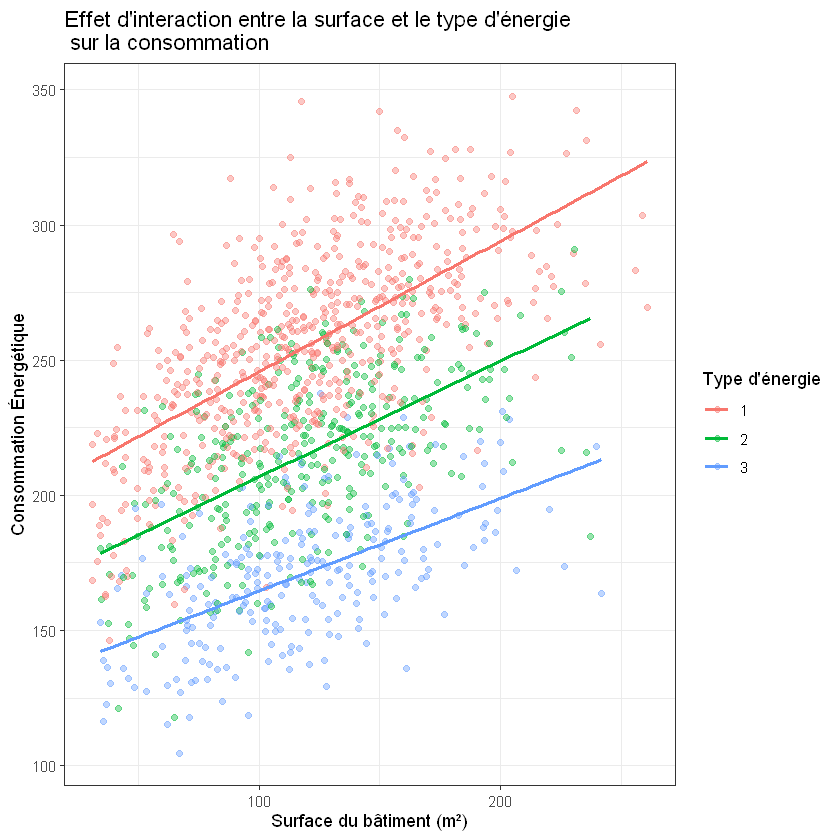

In [25]:
ggplot(donnees) +
  aes(x = surface, y = conso_energie, color = factor(type_energie)) +
  geom_point(alpha = 0.4) + # Les points pour voir la distribution
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE) + # Les pentes d'interaction
  labs(title = "Effet d'interaction entre la surface et le type d'énergie \n sur la consommation",
       x = 'Surface du bâtiment (m²)',
       y = 'Consommation Énergétique',
       color = 'Type d\'énergie') +
  theme_bw()

Le graphique confirme notre intuition initiale. Les droites de régression ne sont pas parallèles :

•	La pente est plus raide pour le Type 1, indiquant une forte sensibilité.

•	La pente est plus douce pour le Type 3, indiquant une progression plus modérée.

Cette démarche justifie l'introduction du terme d'interaction surface * type_energie. Cela permet au modèle de ne plus considérer l'effet de la surface comme une constante, mais comme un effet modulé par le combustible, ce qui améliore la précision des prédictions.


###### 4.2.3 —  Exécution du modèle d'interaction 

In [26]:
# Création du modèle avec interaction et polynôme
model_inter <- lm(conso_energie ~ poly(surface, 2, raw = TRUE) * type_energie + 
                    hauteur_plafond + isolation + nbr_occupants + 
                    temperature_moy + age_batiment+orientation, 
                  data = donnees)

# Affichage des résultats
summary(model_inter)


Call:
lm(formula = conso_energie ~ poly(surface, 2, raw = TRUE) * type_energie + 
    hauteur_plafond + isolation + nbr_occupants + temperature_moy + 
    age_batiment + orientation, data = donnees)

Residuals:
    Min      1Q  Median      3Q     Max 
-45.057 -10.515  -0.339   9.707  51.296 

Coefficients:
                                              Estimate Std. Error t value
(Intercept)                                  1.494e+02  5.602e+00  26.667
poly(surface, 2, raw = TRUE)1                9.658e-01  5.855e-02  16.495
poly(surface, 2, raw = TRUE)2               -1.897e-03  2.253e-04  -8.418
type_energie2                               -2.797e+01  6.605e+00  -4.234
type_energie3                               -6.396e+01  7.279e+00  -8.787
hauteur_plafond                              1.796e+01  1.463e+00  12.271
isolation                                   -2.892e+00  2.333e-01 -12.394
nbr_occupants                                5.139e+00  2.941e-01  17.471
temperature_moy          

Une hypothèse d'interaction entre la surface et le type_energie a été testée suite à l'observation de pentes potentiellement divergentes sur les graphiques de diagnostic. Cependant, le test statistique a révélé des p-values non significatives (p>0.5), indiquant que l'effet de la surface sur la consommation reste stable quel que soit le type d'énergie utilisé.

### Section E: Synthèse et recommandations

##### Tableau Comparatif des Modèles

| Modèle | $R^2$ Ajusté | Erreur (RSE) | AIC | ANOVA (Significativité) | Verdict |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **1. Linéaire** | 0,8839 | 15,6 | 10076 | - | Base de référence |
| **2. Polynomial** | 0,8927 | 15,0 | 9983 | < 2e-16 | Choix Final |
| **3. Avec Interaction** | 0,8950 | 14,8| 9960 | < 2e-16 | Performance pure |

Pour finaliser notre démarche, nous avons mis en compétition les trois structures : le modèle linéaire complet, le polynomial, et celui incluant l'interaction.

le passage au modèle polynomial améliore le R2 et baisse l'AIC. L'ANOVA confirme, avec une p-value extrêmement faible, que cette complexité supplémentaire est mathématiquement justifiée.

Cependant, concernant l'interaction, nous faisons face à un arbitrage : bien qu'elle affiche théoriquement les meilleurs scores globaux, ses coefficients individuels manquent de stabilité. Par principe de parsimonie, nous avons fait un choix stratégique : nous retenons le Modèle Polynomial. Il offre un équilibre parfait entre une haute performance et une stabilité indispensable pour nos prédictions.

##### Création d'un scénario de test

In [30]:
# Création d'un bâtiment fictif
nouveau_batiment <- data.frame(
  surface = 120,
  hauteur_plafond = 2.5,
  isolation = 7.0,
  nbr_occupants = 3,
  temperature_moy = 10.0,
  orientation = 4.5,
  type_energie = factor(2, levels = levels(donnees$type_energie)),
  age_batiment = 35
)

# Calcul de la prédiction avec l'intervalle de PRÉDICTION (95%)
resultat_pred <- predict(m_poly, newdata = nouveau_batiment, interval = "prediction", level = 0.95)

# Affichage du résultat
print(resultat_pred)

       fit      lwr      upr
1 213.9772 184.4916 243.4628


fit = 213.98 → Le modèle prédit une consommation énergétique de ~214 kWh/m²/an pour ce bâtiment fictif (surface=120m², isolation=7, 3 occupants, etc.)
lwr = 184.49 et upr = 243.46 → Avec un niveau de confiance de 95%, la consommation réelle d'un bâtiment individuel aux mêmes caractéristiques devrait se situer entre 184 et 243 kWh/m²


### 5.2 - SYNTHÈSE À DESTINATION DE L'ADEME

In [24]:
# Performance du modèle final (m_poly)
#Note : les métriques ci-dessous sont calculées sur l'ensemble des données d'entraînement (pas de split train/test)
residus <- residuals(m_poly)  
rmse <- sqrt(mean(residus^2))
mae  <- mean(abs(residus))

cat("Performance du modele final :\n")
cat("R2 ajuste :", round(summary(m_poly)$adj.r.squared, 4), "\n")
cat("RMSE      :", round(rmse, 3), "kWh\n")
cat("MAE       :", round(mae, 3),  "kWh\n")

# Coefficients standardises pour quantifier l'importance
library(lm.beta)
coeffs_finaux <- lm.beta(m_poly)
summary(coeffs_finaux)

Performance du modele final :
R2 ajuste : 0.8927 
RMSE      : 14.928 kWh
MAE       : 11.987 kWh



Call:
lm(formula = conso_energie ~ poly(surface, 2, raw = TRUE) + hauteur_plafond + 
    isolation + nbr_occupants + temperature_moy + orientation + 
    type_energie + age_batiment, data = donnees)

Residuals:
    Min      1Q  Median      3Q     Max 
-44.529 -10.234  -0.123  10.411  50.495 

Coefficients:
                                Estimate Standardized Std. Error t value
(Intercept)                    1.561e+02           NA  5.283e+00  29.554
poly(surface, 2, raw = TRUE)1  8.804e-01    8.353e-01  4.506e-02  19.536
poly(surface, 2, raw = TRUE)2 -1.732e-03   -4.250e-01  1.743e-04  -9.939
hauteur_plafond                1.818e+01    1.166e-01  1.474e+00  12.332
isolation                     -2.882e+00   -1.158e-01  2.356e-01 -12.232
nbr_occupants                  5.165e+00    1.649e-01  2.959e-01  17.455
temperature_moy               -3.283e+00   -2.785e-01  1.116e-01 -29.431
orientation                   -1.983e+00   -1.124e-01  1.670e-01 -11.876
type_energie2                 -4.1

**Performance du modèle final :**
Le modèle polynomial retenu explique 89,27 % de la variabilité de la consommation énergétique des bâtiments (R² ajusté = 0,8927). Le modèle présente un RMSE de 14,928 kWh et un MAE de 11,987 kWh, ce qui indique que les erreurs d'ajustement restent faibles compte tenu de l'étendue des valeurs observées (104 à 347 kWh). Toutes les variables sont hautement significatives (p < 2e-16).

**Principaux facteurs et leur impact :**
Le type d'énergie est le facteur le plus déterminant : passer de l'électrique aux énergies renouvelables réduit la consommation de 84 kWh en moyenne, et au gaz de 42 kWh. La surface du bâtiment arrive en deuxième position, avec un effet non linéaire — l'impact de chaque m² supplémentaire diminue pour les très grands bâtiments. L'âge du bâtiment et la température extérieure jouent également un rôle important, tandis que l'isolation, la hauteur sous plafond et l'orientation ont un effet plus modéré.

**Recommandations concrètes pour l’Ademe afin de réduire la consommation énergétique des bâtiments:**
- Prioriser la transition vers les énergies renouvelables, levier le plus puissant avec −84 kWh par bâtiment
- Cibler la rénovation du parc ancien, dont la dégradation thermique augmente significativement la consommation
- Renforcer les exigences d'isolation dans les nouvelles constructions pour limiter la dégradation future

**Discussion des Limites et Perspectives**
Choisir un modèle, c'est aussi en comprendre les failles. Nous avons identifié des limites spécifiques pour chaque approche :

Le Linéaire souffre d'une additivité rigide :  il traite la surface comme une variable isolée et constante. Il suppose qu'ajouter 10 m^2 à un petit studio de 20 m^2 a exactement le même impact énergétique que les ajouter à un entrepôt de 500 m^2.

Le modèle avec Interaction, à l'inverse, présente un risque de sur-apprentissage (overfitting). En voulant coller trop près aux données actuelles, il risque de capturer du "bruit" statistique et de perdre en efficacité sur de nouveaux bâtiments.

Notre modèle Polynomial, bien qu'excellent, a pour limite sa sensibilité aux valeurs extrêmes. Il est extrêmement fiable dans l'intervalle de nos données (50 à 300 m²), mais il ne saurait être extrapolé à des structures hors normes, comme des gratte-ciel, sans risque d'erreur.

Bien que notre modèle polynomial atteigne une performance élevée (R2 = 0,89), une part de la variance (11 %) reste inexpliquée. Pour atteindre une précision supérieure, il serait nécessaire d'intégrer des variables qui influencent directement la réalité thermique, mais qui ne sont pas présentes dans notre jeu de données actuel :

-Le Facteur Humain (Comportemental) : Le modèle suppose un usage standardisé des locaux. Or, les habitudes des occupants (température de consigne à 19°C vs 23°C, fréquence d'aération) constituent une variable aléatoire majeure qui impacte lourdement la consommation réelle.

-L'Efficacité Réelle des Équipements : Si le type d'énergie est renseigné, l'âge et l'état de maintenance des systèmes de chauffage ne le sont pas. Une chaudière vétuste présentera un rendement bien inférieur aux prévisions théoriques du modèle, créant un écart avec les données observées.

**Conclusion :** Cette analyse nous rappelle que notre modèle reste une représentation simplifiée de la réalité. Ces pistes constituent des axes d'amélioration pour de futures itérations, visant à transformer ce modèle prédictif en un outil de diagnostic thermique de haute précision.